In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import mean_squared_error

from pytorch_forecasting import TimeSeriesDataSet, RecurrentNetwork
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import RMSE

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.callbacks.progress import TQDMProgressBar
from lightning.pytorch.loggers import TensorBoardLogger

from loss_funcs import *
from data_loading import *

print(f"PyTorch version  : {torch.__version__}")
print(f"CUDA available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    torch.set_float32_matmul_precision("medium")
    print("float32 matmul precision set to 'medium'")

PyTorch version  : 2.6.0+cu124
CUDA available   : True
GPU              : NVIDIA GeForce RTX 3090
float32 matmul precision set to 'medium'


In [2]:
MAX_PREDICTION_LENGTH = 36
MAX_ENCODER_LENGTH    = 36

BATCH_SIZE    = 1024 * 2
MAX_EPOCHS    = 50
LEARNING_RATE = 3e-3

# LSTM-specific hyperparameters
HIDDEN_SIZE = 64
RNN_LAYERS  = 2
DROPOUT     = 0.1
CELL_TYPE   = "LSTM"   # or "GRU"

In [3]:
print("Loading train …")
train = load_and_prepare(TRAIN_PATH_WITH_DATETME)
print(f"train: {train.shape}  range: {train['datetime'].min()} → {train['datetime'].max()}")

print("Loading val   …")
val = load_and_prepare(VAL_PATH_WITH_DATETME)

print("Loading test  …")
test = load_and_prepare(TEST_PATH_WITH_DATETME)

print(f"val : {val.shape}")
print(f"test: {test.shape}")

Loading train …
train: (4586151, 38)  range: 2024-01-01 01:00:00+02:00 → 2025-06-30 23:00:00+03:00
Loading val   …
Loading test  …
val : (293880, 38)
test: (295430, 38)


In [4]:
train["data_subset"] = "train"
val["data_subset"]   = "val"
test["data_subset"]  = "test"

all_data = (
    pd.concat([train, val, test], ignore_index=True)
    .sort_values([GROUP_COL, "time_idx"])
    .reset_index(drop=True)
)

training_cutoff = train["time_idx"].max()
val_cutoff      = val["time_idx"].max()
test_cutoff     = test["time_idx"].max()

print(f"training cutoff : {training_cutoff}")
print(f"val cutoff      : {val_cutoff}")
print(f"test cutoff     : {test_cutoff}")

for cols in cat_columns + calendar_cols:
    all_data[cols] = all_data[cols].astype(str)

weather_cols_to_keep = [
    "temperature_2m",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation",
    "direct_normal_irradiance"
]

def filter_existing(lst, df):
    return [c for c in lst if c in df.columns]

training = TimeSeriesDataSet(
    all_data[all_data["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target=Y_COL,
    group_ids=[GROUP_COL],
    min_encoder_length=MAX_ENCODER_LENGTH // 2,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=1,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=filter_existing(cat_columns, all_data),
    static_reals=filter_existing(['max_power', 'max_solar', 'max_ev', 'latitude', 'longitude'], all_data),
    time_varying_known_reals=filter_existing(weather_cols_to_keep + ['sell_bm_price', 'buy_bm_price', 'dam_price'], all_data) + ["time_idx"],
    time_varying_known_categoricals=filter_existing(calendar_cols, all_data),
    time_varying_unknown_reals=[Y_COL],
    target_normalizer=GroupNormalizer(groups=[GROUP_COL], transformation="softplus"),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    all_data[all_data["time_idx"] <= val_cutoff],
    predict=True,
    stop_randomization=True,
)

NUM_WORKERS = 0
train_loader = training.to_dataloader(
    train=True, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = validation.to_dataloader(
    train=False, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True,
)

print(f"\nTraining   batches : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")

training cutoff : 13125
val cutoff      : 13869
test cutoff     : 14617

Training   batches : 2246
Validation batches : 1


In [5]:
lstm = RecurrentNetwork.from_dataset(
    training,
    learning_rate=LEARNING_RATE,
    hidden_size=HIDDEN_SIZE,
    rnn_layers=RNN_LAYERS,
    dropout=DROPOUT,
    cell_type=CELL_TYPE,
    loss=RMSE(),
    optimizer="adam",
    reduce_on_plateau_patience=4,
    log_interval=-1,
)
print(f"Number of parameters: {lstm.size() / 1e3:.1f}k")

Number of parameters: 101.3k


In [6]:
class MetricPrinterCallback(pl.Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return
        m = trainer.callback_metrics
        print(
            f"[epoch={trainer.current_epoch:3d} | step={trainer.global_step:6d}]"
            f"  train_loss={float(m.get('train_loss', float('nan'))):.4f}"
            f"  val_loss={float(m.get('val_loss', float('nan'))):.4f}"
        )


early_stop = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=5, verbose=True, mode="min",
)
lr_logger  = LearningRateMonitor()
checkpoint = ModelCheckpoint(
    dirpath="../models/lstm/",
    filename="lstm-{epoch:02d}-{val_loss:.4f}",
    monitor="val_loss",
    mode="min",
    save_top_k=2,
)
progress_bar = TQDMProgressBar(refresh_rate=20)
logger = TensorBoardLogger("../tb_logs", name="lstm_gas_stations")

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
print(f"Using {accelerator} accelerator")

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=accelerator,
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_logger, checkpoint, progress_bar, MetricPrinterCallback()],
    logger=logger,
    enable_progress_bar=True,
    log_every_n_steps=10,
    precision="bf16-mixed",
    val_check_interval=0.25,
    accumulate_grad_batches=4,
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Using gpu accelerator


In [7]:
trainer.fit(
    lstm,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)

print(f"\nBest checkpoint : {checkpoint.best_model_path}")
print(f"Best val_loss   : {checkpoint.best_model_score:.6f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss             │ RMSE           │      0 │ train │     0 │
│ 1 │ logging_metrics  │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings       │ MultiEmbedding │ 19.4 K │ train │     0 │
│ 3 │ rnn              │ LSTM           │ 81.9 K │ train │     0 │
│ 4 │ output_projector │ Linear         │     65 │ train │     0 │
└───┴──────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 101 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 101 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

[epoch=  1 | step=   842]  train_loss=2.1444  val_loss=9.2190


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 8.019. Signaling Trainer to stop.


[epoch=  1 | step=   982]  train_loss=1.6981  val_loss=9.1682

Best checkpoint : C:\Users\Lev\Documents\GitHub\Diploma\models\lstm\lstm-epoch=00-val_loss=8.0195.ckpt
Best val_loss   : 8.019479


In [8]:
best_lstm = RecurrentNetwork.load_from_checkpoint(
    checkpoint.best_model_path,
    weights_only=False,
)
best_lstm.eval()

# Quick sanity check on the last validation window
result = best_lstm.predict(
    val_loader,
    return_index=True,
    trainer_kwargs={"accelerator": accelerator},
)

pred_tensor = result[0].cpu().numpy()
val_index   = result[2]

rows = []
for i, (_, idx_row) in enumerate(val_index.iterrows()):
    for step in range(MAX_PREDICTION_LENGTH):
        rows.append({
            GROUP_COL:  idx_row[GROUP_COL],
            "time_idx": idx_row["time_idx"] + step,
            "pred":     pred_tensor[i, step],
        })

val_expanded = pd.DataFrame(rows)
val_merged   = val_expanded.merge(
    all_data[[GROUP_COL, "time_idx", Y_COL]],
    on=[GROUP_COL, "time_idx"], how="inner",
)

print(f"Aligned samples: {len(val_merged)}")
print("\n── Quick Val Metrics (last window only) ──────────────────")
print(f"SMAPE : {smape(val_merged[Y_COL], val_merged['pred']):.4f}")
print(f"RMSE  : {rmse( val_merged[Y_COL], val_merged['pred']):.4f}")
print(f"MAPE  : {mape( val_merged[Y_COL], val_merged['pred']):.2f} %")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Aligned samples: 14220

── Quick Val Metrics (last window only) ──────────────────
SMAPE : 21.1863
RMSE  : 8.0207
MAPE  : 27.43 %


In [9]:
def rolling_eval(model, base_dataset, full_data, start_idx, end_idx):
    """
    Slide MAX_PREDICTION_LENGTH-step windows over (start_idx, end_idx].
    Actual y values are used as encoder context — no error propagation.
    """
    records = []
    for window_end in range(
        start_idx + MAX_PREDICTION_LENGTH,
        end_idx + 1,
        MAX_PREDICTION_LENGTH,
    ):
        ds = TimeSeriesDataSet.from_dataset(
            base_dataset,
            full_data[full_data["time_idx"] <= window_end],
            predict=True,
            stop_randomization=True,
        )
        loader = ds.to_dataloader(
            train=False, batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS, pin_memory=True,
        )
        result = model.predict(
            loader, return_index=True,
            trainer_kwargs={"accelerator": accelerator},
        )
        pred_np = result[0].cpu().numpy()
        for i, (_, idx_row) in enumerate(result[2].iterrows()):
            for s in range(MAX_PREDICTION_LENGTH):
                t = idx_row["time_idx"] + s
                if t > end_idx:
                    break
                records.append({
                    GROUP_COL:  idx_row[GROUP_COL],
                    "time_idx": t,
                    "pred":     pred_np[i, s],
                })

    preds_df = pd.DataFrame(records)
    return preds_df.merge(
        full_data[[GROUP_COL, "time_idx", Y_COL, 'dam_price', 'sell_bm_price', 'buy_bm_price']],
        on=[GROUP_COL, "time_idx"], how="inner",
    )


labelled_data = all_data[all_data["time_idx"] <= test_cutoff]

print("── Validation ──────────────────────────────────────────────")
val_eval = rolling_eval(best_lstm, training, labelled_data, training_cutoff, val_cutoff)
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE  : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE  : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")

print("\n── Test ────────────────────────────────────────────────────")
test_eval = rolling_eval(best_lstm, training, labelled_data, val_cutoff, test_cutoff)
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE  : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE  : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")

── Validation ──────────────────────────────────────────────


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless

Aligned samples : 284,400
SMAPE : 23.5159
RMSE  : 8.2629
MAPE  : 32.07 %

── Test ────────────────────────────────────────────────────


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
💡 Tip: For seamless

Aligned samples : 284,400
SMAPE : 24.2861
RMSE  : 9.1196
MAPE  : 37.84 %


In [10]:
def _prices(df):
    return df["dam_price"].values, df["sell_bm_price"].values, df["buy_bm_price"].values

print("── Validation ──────────────────────────────────────────────")
print(f"Aligned samples : {len(val_eval):,}")
print(f"SMAPE     : {smape(val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"RMSE      : {rmse( val_eval[Y_COL], val_eval['pred']):.4f}")
print(f"MAPE      : {mape( val_eval[Y_COL], val_eval['pred']):.2f} %")
print(f"MONEY     : {money(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval)):.0f}")
print(f"MONEY_PCT : {money_pct(val_eval[Y_COL], val_eval['pred'], *_prices(val_eval)):.2f}%")

print("\n── Test ────────────────────────────────────────────────────")
print(f"Aligned samples : {len(test_eval):,}")
print(f"SMAPE     : {smape(test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"RMSE      : {rmse( test_eval[Y_COL], test_eval['pred']):.4f}")
print(f"MAPE      : {mape( test_eval[Y_COL], test_eval['pred']):.2f} %")
print(f"MONEY     : {money(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval)):.0f}")
print(f"MONEY_PCT : {money_pct(test_eval[Y_COL], test_eval['pred'], *_prices(test_eval)):.2f}%")

── Validation ──────────────────────────────────────────────
Aligned samples : 284,400
SMAPE     : 23.5159
RMSE      : 8.2629
MAPE      : 32.07 %
MONEY     : 2439466
MONEY_PCT : 8.61%

── Test ────────────────────────────────────────────────────
Aligned samples : 284,400
SMAPE     : 24.2861
RMSE      : 9.1196
MAPE      : 37.84 %
MONEY     : 2966784
MONEY_PCT : 10.42%


In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_forecast(eval_df, eic_code, start_dt=None, end_dt=None):
    df = eval_df.merge(
        all_data[[GROUP_COL, "time_idx", "datetime"]],
        on=[GROUP_COL, "time_idx"], how="inner",
    )
    df = df[df[GROUP_COL] == eic_code].sort_values("datetime")
    if df.empty:
        raise ValueError(f"No data for EiC code: {eic_code!r}")
    if start_dt is not None:
        df = df[df["datetime"] >= pd.Timestamp(start_dt)]
    if end_dt is not None:
        df = df[df["datetime"] <= pd.Timestamp(end_dt)]
    if df.empty:
        raise ValueError("No data in the specified datetime range.")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(df["datetime"], df[Y_COL],  label="True",      linewidth=1, color="steelblue")
    ax.plot(df["datetime"], df["pred"], label="Predicted", linewidth=1, color="tomato", alpha=0.85)
    ax.set_title(
        f"{eic_code}  |  MAPE={mape(df[Y_COL], df['pred']):.3f}"
        f"  RMSE={rmse(df[Y_COL], df['pred']):.2f}"
        f"  ({df['datetime'].min().date()} \u2013 {df['datetime'].max().date()})"
    )
    ax.set_xlabel("Datetime")
    ax.set_ylabel(Y_COL)
    ax.legend()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
    fig.autofmt_xdate(rotation=0, ha="center")
    plt.tight_layout()
    plt.show()


# Example:
# plot_forecast(val_eval,  eic_code="<code>")
# plot_forecast(test_eval, eic_code="<code>", start_dt="2025-08-25", end_dt="2025-08-26")

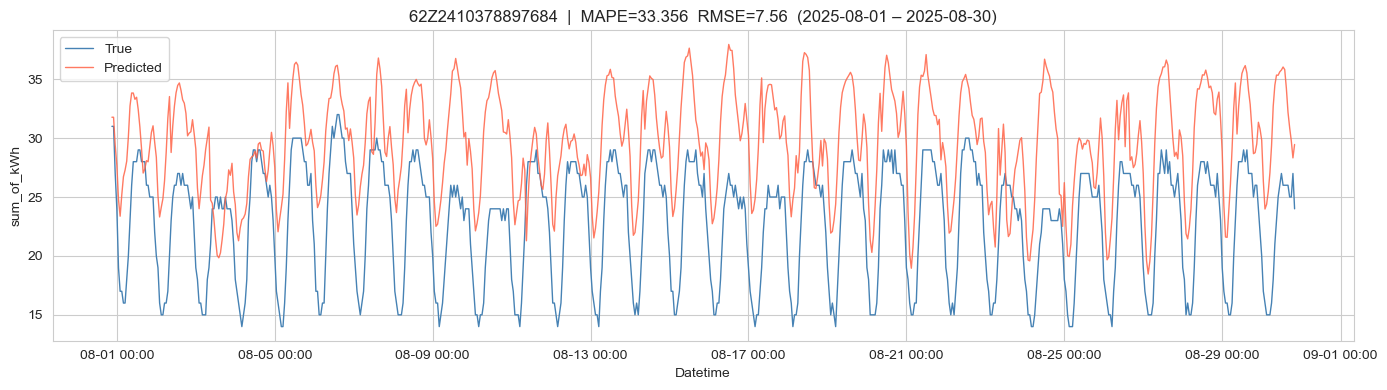

In [12]:
plot_forecast(test_eval, eic_code='62Z2410378897684')